In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from etl.util import prepare_dataset_without_leakage
from ml_features.features import prepare_features
from ml_features.customer_features import create_customer_features
from ml_features.sequence_features  import create_sequence_features
from ml_features.brand_features import create_brand_features
from ml_features.model_features import create_model_features
from ml_features.market_features import create_market_features
from ml_features.equipment_features import create_equipment_features
from ml_features.solution_complexity_features import create_solution_complexity_features
from ml_features.timeline_features import create_timeline_features, create_advanced_timeline_features, create_timeline_interaction_features
from ml_features.role_features import create_commercial_role_features
from ml_features.process_features import create_process_features
from ml_features.correction_features import create_correction_features
from ml_features.catboost_interaction_features import create_catboost_interaction_features
from ml_features.efficiency_interation_features import create_efficiency_interaction_features
from ml_features.engagement_interation_features import create_engagement_interaction_features
from ml_features.advanced_features import create_advanced_interaction_features, create_conversion_pattern_features, create_precision_optimization_features, create_price_dominant_features
from ml_features.price_binning_features import create_price_binning_features
from ml_features.simulation_discovery import create_simulation_discovery_features
from ml_training.train_xgb import train_xgb
from ml_evaluation.dashboard import model_evaluation_report
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
import pandas as pd

df_quotes = pd.read_csv('cleaned_quote_data.csv')
print("Unique region names in your data:")
print(df_quotes['nom_region'].value_counts())

Unique region names in your data:
nom_region
Normandie               15229
Auvergne-Rhône-Alpes     7349
Île-de-France            6294
Hauts-de-France          4468
Sud                       674
Name: count, dtype: int64


In [3]:
# FILTER TO HEAT PUMP → STOVE OPPORTUNITY CUSTOMERS
print("\n🎯 FILTERING TO HEAT PUMP → STOVE OPPORTUNITY")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with heat pump
has_heat_pump = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Pompe à chaleur' in x.values
)

# Get customers with stove
has_stove = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Poêle' in x.values
)

# Heat pump → Stove opportunity: has heat pump, no stove
hp_to_stove_ids = has_heat_pump[has_heat_pump & (~has_stove)].index.tolist()

# Filter data
df_quotes_hp_stove = df_quotes[df_quotes['numero_compte'].isin(hp_to_stove_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Heat pump → Stove opportunity: {len(hp_to_stove_ids):,} customers")
print(f"Quotes: {len(df_quotes_hp_stove):,}")

# Save to file
df_quotes_hp_stove.to_csv('cleaned_quote_data_hp_stove.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_hp_stove.csv")


🎯 FILTERING TO HEAT PUMP → STOVE OPPORTUNITY
Original customers: 23,888
Heat pump → Stove opportunity: 4,467 customers
Quotes: 7,025

✅ Saved to cleaned_quote_data_hp_stove.csv


In [4]:
df_quotes = pd.read_csv('cleaned_quote_data_hp_stove.csv')


📊 Original quote data: 7,025 quotes from 4,467 customers

🏗️  BUILDING FEATURES FOR COLD REGION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 4,467, Quotes: 6,741
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 4,467 customers | 42.2% converters
⏱️  Execution time: 1.7 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 4,467
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/4,467 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 4,467
   First converters: 1,883 (42.2%)
   Never converters: 2,584

📊 Distribution check:
   Converters with 0 historical quotes: 1,351
   Non-converters with 0 historical quotes: 1,694
   Avg historical quotes - Converters: 0.4
   Avg historical quotes - Non-converters: 0.

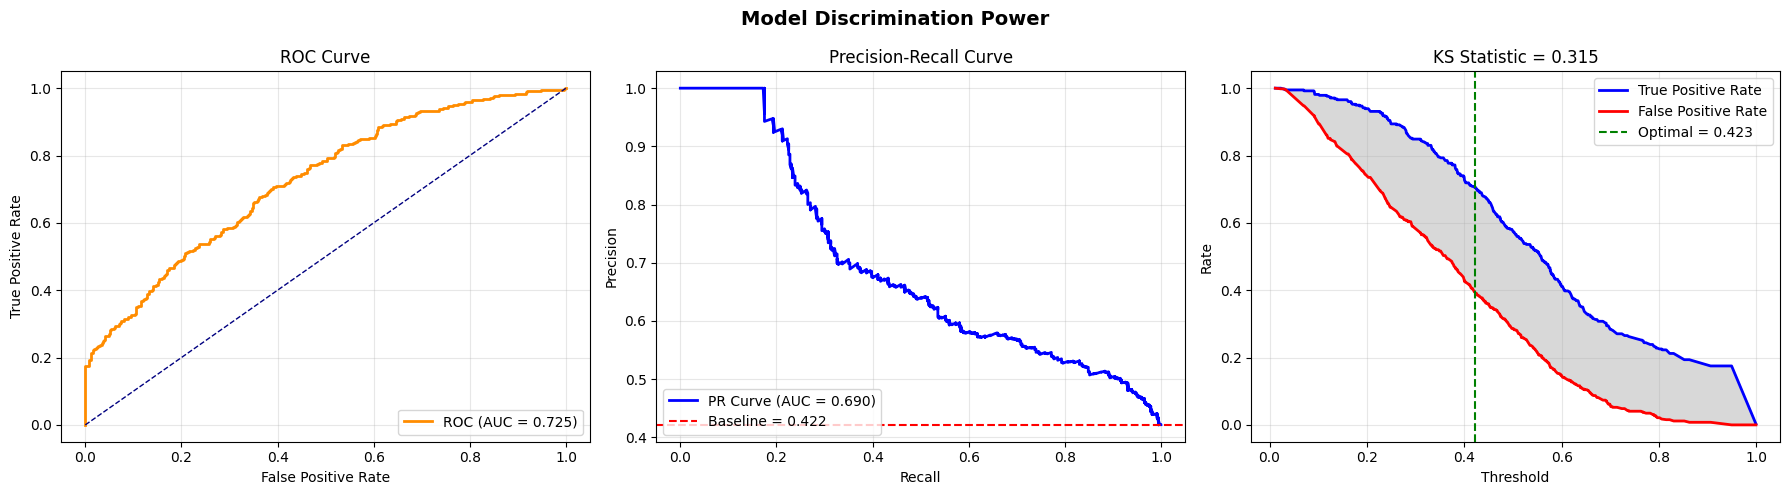

• ROC-AUC: 0.7253
• PR-AUC: 0.6905
• KS Statistic: 0.315 (MODERATE discrimination)
• Optimal Threshold: 0.423

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.960
Decile 10 mean prob: 0.083


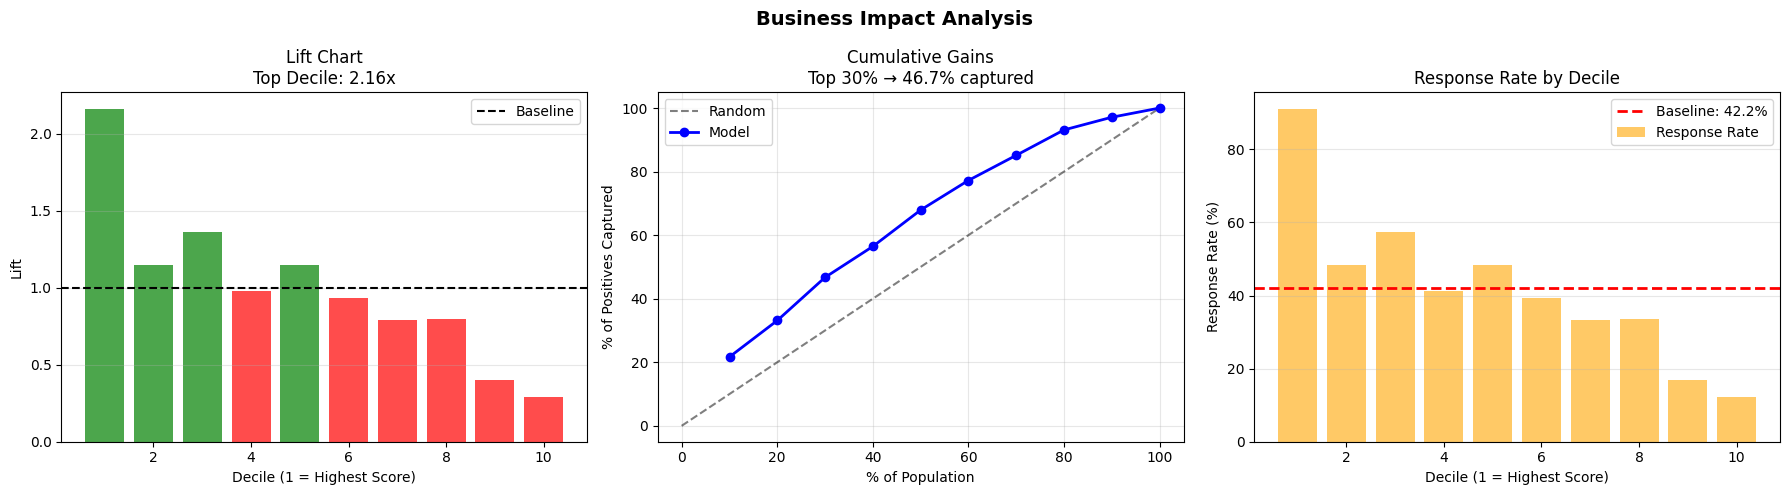

• Top Decile Lift: 0.29x
• Top 30% captures: 46.7% of positives
• Baseline response rate: 42.2%
• Top decile response: 91.1%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


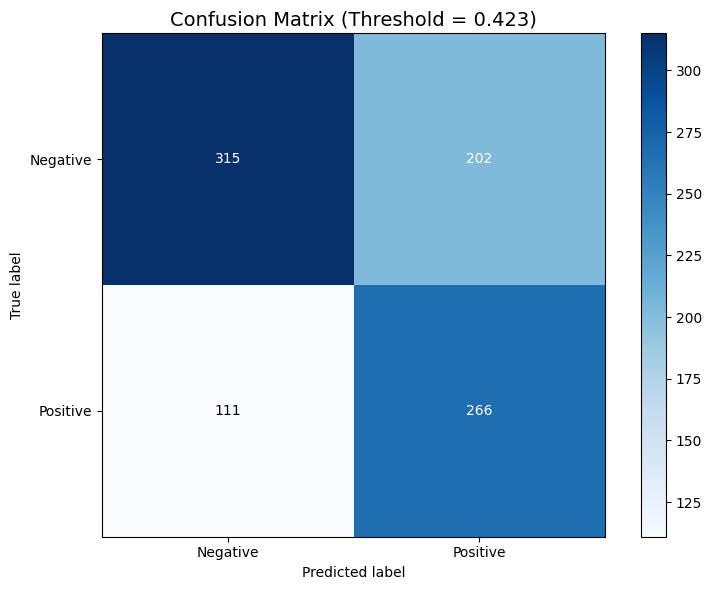

At threshold 0.423:
• Accuracy: 0.650
• Precision: 0.568
• Recall: 0.706
• F1-Score: 0.630
• True Positives: 266
• False Positives: 202
• True Negatives: 315
• False Negatives: 111

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.315 (MODERATE discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.29x better than random
   Coverage: Top 30% → 46.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7253 (Excellent if >0.8)
   PR-AUC: 0.6905 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.423
   Precision at threshold: 0.568
   Recall at threshold: 0.706

🔍 FEATURE IMPORTANCE - COLD REGION MODEL

Top 20 Features:
                          feature  importance
171       quote_consistency_score    0.084912
235           price_x_consistency    0.044328
243                   value_score    0.043050
208          high_value_potential    0.020044
273                avg_price_tier    0.014392
173     decision_efficiency_score    0.013303
97        avg_days_between_quo

In [5]:
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])
print(f"\n📊 Original quote data: {len(df_quotes):,} quotes from {df_quotes['numero_compte'].nunique():,} customers")


# ============================================
# 3. RUN FULL FEATURE PIPELINE ON COLD REGIONS ONLY
# ============================================
print("\n" + "="*80)
print("🏗️  BUILDING FEATURES FOR COLD REGION CUSTOMERS")
print("="*80)

# Create feature list
feature_funcs = [create_customer_features, create_sequence_features, create_brand_features, 
                 create_model_features, create_market_features,
                 create_equipment_features, create_solution_complexity_features,
                 create_timeline_features, create_advanced_timeline_features,
                 create_commercial_role_features, create_process_features,
                 create_correction_features
                ]

new_df = feature_funcs[0](df_quotes)
for func in feature_funcs[1:]:
    new_df_ = func(df_quotes)
    new_df = pd.merge(new_df, new_df_, on='numero_compte', how='left', suffixes=('_dup', ''))
    new_df = new_df.drop(columns=[x for x in new_df.columns if '_dup' in x], errors='ignore')

print(f"\n✅ Customer-level features created: {len(new_df):,} customers")

# ============================================
# 4. ADD INTERACTION FEATURES
# ============================================
print("\n" + "="*80)
print("🔧 ADDING INTERACTION FEATURES")
print("="*80)

new_df = create_timeline_interaction_features(new_df)
new_df, _ = create_catboost_interaction_features(new_df)
new_df, _ = create_efficiency_interaction_features(new_df)
new_df, _ = create_engagement_interaction_features(new_df)
new_df = create_advanced_interaction_features(new_df)
new_df = create_conversion_pattern_features(new_df)
new_df = create_precision_optimization_features(new_df)
new_df = create_price_dominant_features(new_df) 
new_df = create_price_binning_features(new_df)
new_df = create_simulation_discovery_features(new_df)

# ============================================
# 5. PREPARE FEATURES FOR MODELING
# ============================================
print("\n" + "="*80)
print("🔧 ENCODING & PREPARING FOR MODELING")
print("="*80)

X = new_df.drop(columns=['numero_compte', 'converted'], errors='ignore')
y = new_df['converted']
X_clean, y_clean = prepare_features(X, y, "Cold Region Features")

print(f"   Features: {X_clean.shape[1]}, Samples: {X_clean.shape[0]}")

# ============================================
# 6. TRAIN MODEL ON COLD REGION CUSTOMERS
# ============================================
print("\n" + "="*80)
print("🚀 TRAINING MODEL ON COLD REGION CUSTOMERS")
print("="*80)

result = train_xgb(X_clean, y_clean, 'cold_region_model')

# ============================================
# 7. EVALUATE MODEL
# ============================================
print("\n" + "="*80)
print("📊 MODEL EVALUATION - COLD REGION CUSTOMERS")
print("="*80)

df_eval = result['X_test'].copy()
df_eval['converted'] = result['y_test']

model_evaluation_report(df_eval, result['model'], result['features'], 'converted')

# ============================================
# 8. FEATURE IMPORTANCE
# ============================================
print("\n" + "="*80)
print("🔍 FEATURE IMPORTANCE - COLD REGION MODEL")
print("="*80)

feature_importance = pd.DataFrame({
    'feature': result['features'],
    'importance': result['model'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Features:")
print(feature_importance.head(20))

# ============================================
# 9. CHECK SIMULATION-DISCOVERY FEATURES
# ============================================
print("\n" + "="*80)
print("🧪 SIMULATION-DISCOVERY FEATURES IN COLD REGION MODEL")
print("="*80)

simulation_features = [
    'heat_pump_to_stove_opportunity', 
    'boiler_to_ac_opportunity',
    'cold_region_heat_pump',
    'cold_heat_pump_to_stove',
    'follow_up_opportunity'
]

print("\nFeature Importances for Simulation-Discovery Features:")
for feat in simulation_features:
    if feat in feature_importance['feature'].values:
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        rank = feature_importance[feature_importance['feature'] == feat].index[0] + 1
        print(f"  #{rank}: {feat}: {imp:.4f}")
    else:
        print(f"  ❌ {feat}: NOT FOUND")

print("\n" + "="*80)
print("✅ COLD REGION MODEL TRAINING COMPLETE")
print("="*80)

COMPREHENSIVE ERROR ANALYSIS

📊 1. BASIC ERROR METRICS
------------------------------------------------------------
Confusion Matrix:
  True Negatives:     369 (Correctly rejected)
  False Positives:    148 (Predicted YES, actual NO) ← WASTED EFFORT
  False Negatives:    160 (Predicted NO, actual YES) ← MISSED OPPORTUNITIES
  True Positives:     217 (Correctly predicted)

Error Analysis:
  • Total errors: 308 (34.5% of predictions)
  • False Positive rate: 16.6% (wasted sales effort)
  • False Negative rate: 17.9% (missed conversions)

📈 2. PREDICTION CONFIDENCE ANALYSIS
------------------------------------------------------------
Accuracy by Confidence Level:
  • Very Low   confidence: 79.3% accurate (275 predictions)
  • Low        confidence: 63.4% accurate (123 predictions)
  • Medium     confidence: 50.8% accurate (266 predictions)
  • High       confidence: 50.5% accurate (95 predictions)
  • Very High  confidence: 79.3% accurate (135 predictions)

⚠️  Low Confidence Predictions 

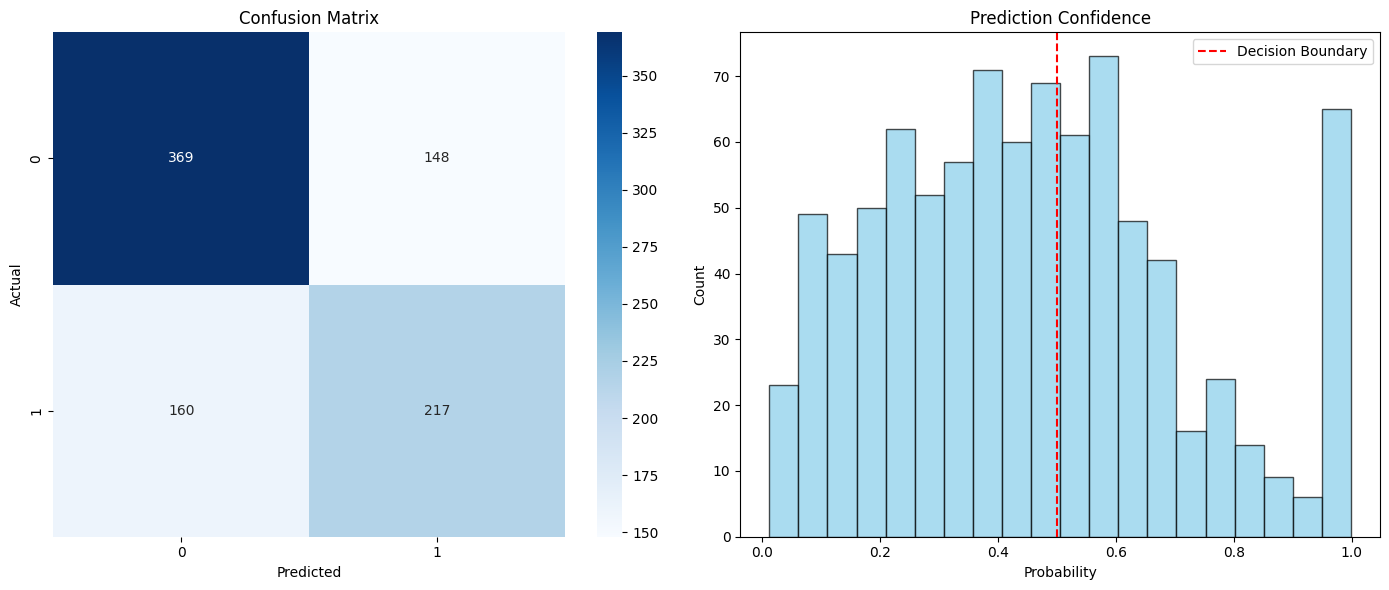

In [6]:
X_test = result['X_test'].copy()  # Make a copy to avoid modifying the original
y_test = result['y_test']
model = result['model']

# Ensure X_test doesn't have the target column
if 'converted' in X_test.columns:
    X_test = X_test.drop(columns=['converted'])

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

# Create a dataframe for error analysis that includes the predictions
error_df = X_test.copy()
error_df['converted'] = y_test
error_df['predicted'] = y_pred
if y_pred_proba is not None:
    error_df['prediction_probability'] = y_pred_proba

error_results = comprehensive_error_analysis(
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
    original_df=error_df,  # Use the properly prepared dataframe
    customer_id_col='numero_compte'
)

analyze_feature_contribution_to_errors(model, X_test, y_test, y_pred)
create_error_visualization(error_results, y_test, y_pred, y_pred_proba)